# Paper figures

Reproduces every figure in the manuscript *Automated calculation of stationary
statistics for Itô stochastic differential equations*, one section per figure.
Each section is self-contained: it computes from the shipped models/simulators
and writes `figures/fig<N>_<name>.png` + `.pdf` (the exact files used in the
paper).

Conventions match the paper: white noise normalized as
$\langle\xi(t)\xi(t')\rangle = 2D\,\delta(t-t')$, so the linear
(Ornstein–Uhlenbeck) stationary variance is $C(0)=D/\mu$.

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'api' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'api')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))   # cwd=notebooks/ for simulations/ paths
os.makedirs('figures', exist_ok=True)
import daedalus as dd

## Figure 1 — failures of the linear approximation (Section II)

**(a)** Quartic OU process $\\partial_t\\phi = -\\mu\\phi - \\varepsilon\\phi^3 + \\xi$
($\\mu = D = 1$): the equal-time variance $C(0)$ from direct simulation falls
below the linear approximation $D/\\mu$ as $\\varepsilon$ grows — a moment-closure
failure the linear/Gaussian ansatz cannot see. The pipeline\'s loop-corrected
curves (dashed, revisited in Section VI) recover it.

**(b)** Mutually exciting 2-neuron Hawkes process with **delta (instantaneous)
synapses**, stationary mean rate vs. coupling scale $s$ ($w\\to s\\,w$). The
**linear** transfer $\\phi=av$ is exact (simulation on the self-consistent
line). The **quadratic** transfer $\\phi=av^2$ undershoots: the naive closure
$\\langle v^2\\rangle\\to\\langle v\\rangle^2$ neglects the voltage variance
(Jensen), and the gap grows with coupling as the process approaches instability.
Delta synapses are essential here — a filtered (alpha) synapse over-averages the
voltage and the closure error all but vanishes.

In [2]:
# ── panel (a): OU quartic, C(0) vs eps ───────────────────────────────────────
from simulations.ou_langevin_sim_numba import sim_ou_quartic_numba

mu, D = float(1.0), float(1.0)
eps_grid = [float(e) for e in (0.0, 0.02, 0.04, 0.06, 0.08, 0.10)]
model, mod = dd.load_model('ou_quartic')

# simulation: stationary variance of finely-binned x (dt_bin << 1/mu)
dt_sim, dt_bin = float(0.01), float(0.02)
T_sim, N_RUNS  = float(2.0e5), int(4)
n_steps        = int(T_sim / dt_sim)
bs             = int(max(round(dt_bin / dt_sim), 1))
n_bins         = int(n_steps // bs)
_ = sim_ou_quartic_numba(int(1000), dt_sim, mu, float(0.05), D, float(0.0),
                         bs, int(100), int(0))               # JIT warmup
sim_C0, sim_err = [], []
t0 = time.perf_counter()
for eps in eps_grid:
    vs = []
    for r in range(N_RUNS):
        xb = sim_ou_quartic_numba(n_steps, dt_sim, mu, eps, D, float(0.0),
                                  bs, n_bins, int(1000 + r))
        vs.append(float(np.var(xb)))
    sim_C0.append(np.mean(vs)); sim_err.append(np.std(vs, ddof=1) / np.sqrt(N_RUNS))
print('OU sims: %.1fs' % (time.perf_counter() - t0))

# pipeline: tree / +1-loop / +2-loop equal-time variance (eps=0 is the free
# model: tree = D/mu exactly, loop corrections vanish — no run needed)
th = {0: [], 1: [], 2: []}
t0 = time.perf_counter()
for eps in eps_grid:
    if eps == 0.0:
        for ell in th: th[ell].append(D / mu)
        continue
    cfg = dd.Config(k=2, max_ell=2, external_fields=[('dx', 1), ('dx', 1)],
                    parameters={'mu': mu, 'eps': eps, 'D': D},
                    tau_grid=(-2.0, 2.0, 5), parallel=False)
    res = dd.run(model, cfg, mod)
    i0 = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
    run = 0.0
    for ell in (0, 1, 2):
        run += float(np.real(res['C_tau_by_ell'][ell])[i0])
        th[ell].append(run)
print('OU pipeline: %.1fs' % (time.perf_counter() - t0))

OU sims: 10.1s
OU pipeline: 1.8s


In [3]:
# ── panel (b): 2-neuron Hawkes with DELTA (instantaneous) synapses ───────
# The synaptic kernel is a delta function: spikes drive the voltage directly,
# so the ONLY smoothing is the membrane time constant tau_v.  A filtered (alpha)
# synapse over-averages the voltage and hides the closure error; delta synapses
# keep the fluctuations, so the quadratic naive closure visibly undershoots.
from simulations.hawkes_sim_multipop_numba import (
    sim_hawkes_multipop_numba, sim_hawkes_multipop_quad_numba)

a    = np.array([0.44, 0.44])          # transfer gain, phi = a v (lin) / a v^2 (quad)
Em   = np.array([0.80, 0.80])          # baseline drive
tauv = np.array([1.0, 1.0])            # membrane time constant
taug = np.full((2, 2), 0.05)           # fast synapse ~ delta (tau_syn << tau_mem)
W0   = np.array([[0.25, 0.25], [0.20, 0.30]])
A    = np.diag(a)
s_grid = [float(x) for x in (0.0, 0.2, 0.4, 0.55, 0.7, 0.8)]

def rates_linear_exact(s):             # n = a v,  v = Em + s W n  (int g = 1)
    return np.linalg.solve(np.eye(2) - s * A @ W0, A @ Em)

def rates_quad_naive(s, iters=600):    # naive closure <v^2> -> <v>^2
    n = a * Em**2
    for _ in range(iters):
        n = 0.5 * n + 0.5 * a * (Em + s * W0 @ n)**2
        if not np.all(np.isfinite(n)) or n.max() > 1e6:
            return np.full(2, np.nan)
    return n

def sim_rate(kind, s, seeds=(11, 12, 13, 14, 15)):
    dt, T = float(0.005), float(1.5e5)
    n_steps = int(T / dt); bs = int(50); n_bins = int(n_steps // bs)
    Ws = np.ascontiguousarray(s * W0)
    f = sim_hawkes_multipop_numba if kind == 'lin' else sim_hawkes_multipop_quad_numba
    rr = []
    for sd in seeds:
        _, _, tot = f(n_steps, dt, tauv, a, Em, Ws, taug, Em.copy(), bs, n_bins, int(sd))
        r = np.asarray(tot, float) / T
        if not np.all(np.isfinite(r)) or r.max() > 1e3:        # runaway guard
            return np.nan, np.nan
        rr.append(r.mean())
    rr = np.array(rr)
    return rr.mean(), rr.std(ddof=1) / np.sqrt(len(rr))

t0 = time.perf_counter()
lin_th  = [rates_linear_exact(s).mean() for s in s_grid]
quad_th = [rates_quad_naive(s).mean() for s in s_grid]
lin_sim,  lin_err  = zip(*[sim_rate('lin', s) for s in s_grid])
quad_sim, quad_err = zip(*[sim_rate('quad', s) for s in s_grid])
print('Hawkes (delta) sims: %.1fs' % (time.perf_counter() - t0))
print('quad naive-vs-sim gap:',
      [('%+.1f%%' % (100 * (qs - qt) / qs)) if np.isfinite(qs) else 'nan'
       for qt, qs in zip(quad_th, quad_sim)])

Hawkes (delta) sims: 59.8s
quad naive-vs-sim gap: ['-0.1%', '+0.1%', '+0.5%', '+1.3%', '+2.7%', '+4.3%']


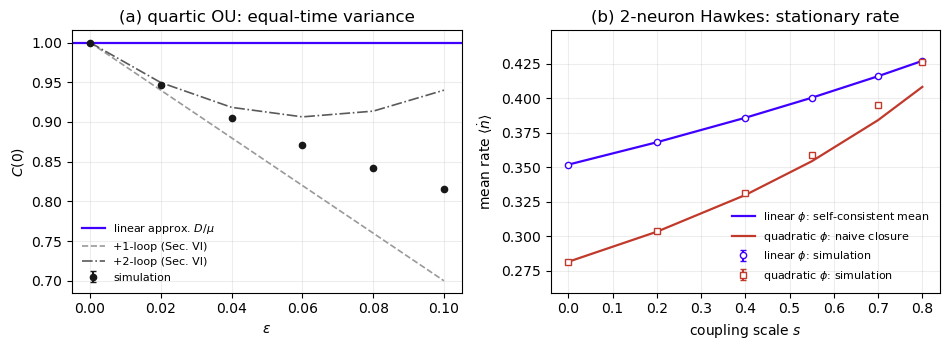

saved figures/fig1_moment_closure.{png,pdf}


In [4]:
# ── assemble Figure 1 ────────────────────────────────────────────────────────
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9.6, 3.6))

axa.axhline(D / mu, color='#3F00FF', lw=1.6, label=r'linear approx. $D/\mu$')
axa.plot(eps_grid, th[1], '--', lw=1.2, color='#9a9a9a', label='+1-loop (Sec. VI)')
axa.plot(eps_grid, th[2], '-.', lw=1.2, color='#5a5a5a', label='+2-loop (Sec. VI)')
axa.errorbar(eps_grid, sim_C0, yerr=sim_err, fmt='o', ms=4.5, color='#181818',
             capsize=2.5, label='simulation', zorder=5)
axa.set_xlabel(r'$\varepsilon$'); axa.set_ylabel(r'$C(0)$')
axa.set_title(r'(a) quartic OU: equal-time variance')
axa.legend(fontsize=8, frameon=False)

axb.plot(s_grid, lin_th, '-', lw=1.6, color='#3F00FF',
         label=r'linear $\phi$: self-consistent mean')
axb.errorbar(s_grid, lin_sim, yerr=lin_err, fmt='o', ms=4.5, color='#3F00FF',
             mfc='white', capsize=2.5, label=r'linear $\phi$: simulation')
axb.plot(s_grid, quad_th, '-', lw=1.6, color='#C0392B',
         label=r'quadratic $\phi$: naive closure')
axb.errorbar(s_grid, quad_sim, yerr=quad_err, fmt='s', ms=4.5, color='#C0392B',
             mfc='white', capsize=2.5, label=r'quadratic $\phi$: simulation')
axb.set_xlabel(r'coupling scale $s$'); axb.set_ylabel(r'mean rate $\langle\dot n\rangle$')
axb.margins(y=0.15)                              # autoscale tight to the data
axb.set_title('(b) 2-neuron Hawkes: stationary rate')
axb.legend(fontsize=8, frameon=False)

for ax in (axa, axb): ax.grid(alpha=0.22)
fig.tight_layout()
fig.savefig('figures/fig1_moment_closure.png', dpi=200, bbox_inches='tight')
fig.savefig('figures/fig1_moment_closure.pdf', bbox_inches='tight')
plt.show()
print('saved figures/fig1_moment_closure.{png,pdf}')